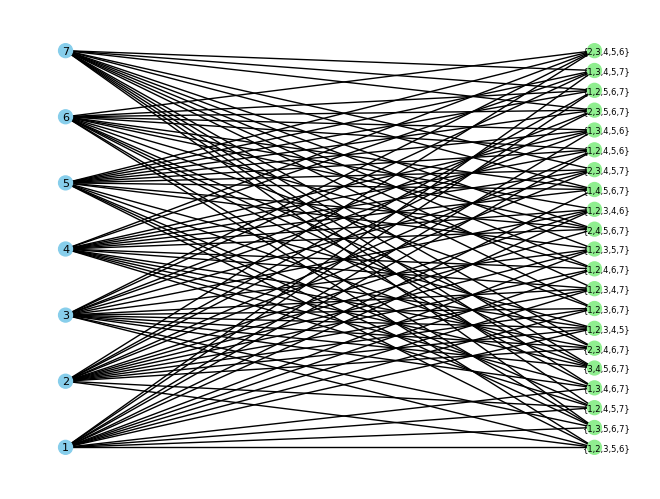

In [4]:
import networkx as nx
from itertools import combinations
import matplotlib.pyplot as plt

def create_G1():
    """
    Creates the bipartite graph G1:
    - Left side: 7 vertices labeled 1, 2, 3, 4, 5, 6, 7
    - Right side: 21 vertices labeled as sets {i,j,k,l,m} representing
      all 5-element subsets of the left side
    - Each right vertex is connected to exactly those 5 left vertices
    """
    G = nx.Graph()
    left_nodes = list(range(1, 8))
    G.add_nodes_from(left_nodes, bipartite=0)

    for subset in combinations(left_nodes, 5):
        node_label = "{" + ",".join(map(str, subset)) + "}"
        G.add_node(node_label, bipartite=1)
        for v in subset:
            G.add_edge(node_label, v)
    return G


G1 = create_G1()

# Compute bipartite layout
left_nodes = [n for n, d in G1.nodes(data=True) if d["bipartite"] == 0]
pos = nx.bipartite_layout(G1, left_nodes)

# Draw nodes and edges
nx.draw(G1, pos, with_labels=False, node_size=100,
        node_color=["skyblue" if d["bipartite"] == 0 else "lightgreen" for n, d in G1.nodes(data=True)])

# Separate labels for left and right nodes
labels_left = {n: n for n in left_nodes}
labels_right = {n: n for n in G1 if n not in left_nodes}

# Shift right-hand labels to the right
label_offset = 0.03  # adjust as needed
pos_labels_right = {n: (x + label_offset, y) for n, (x, y) in pos.items() if n in labels_right}

# Draw labels
nx.draw_networkx_labels(G1, pos, labels=labels_left, font_size=8)
nx.draw_networkx_labels(G1, pos_labels_right, labels=labels_right, font_size=6)

plt.show()


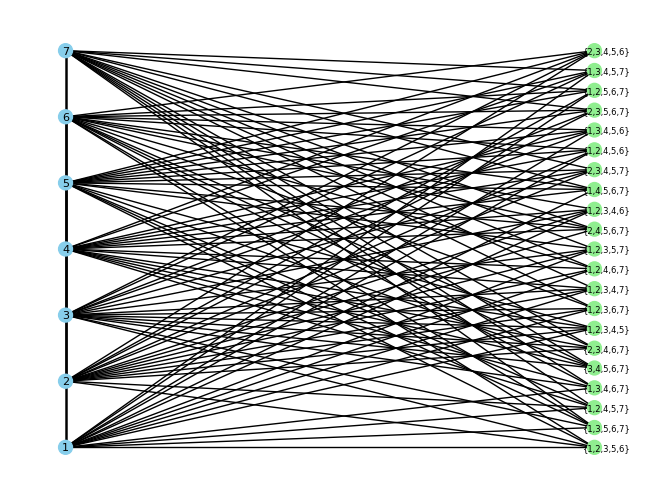

In [ ]:
# import networkx as nx
# from itertools import combinations
# import matplotlib.pyplot as plt

# def create_G1_with_complete_left():
#     """
#     Creates a bipartite graph G1 with:
#     - Left side: 7 vertices labeled 1–7
#     - Right side: 21 vertices labeled as sets {i,j,k,l,m} representing all 5-element subsets of the left side
#     - Each right vertex connected to exactly those 5 left vertices
#     - All left-hand-side vertices fully connected among themselves (forming K7)
#     """
#     G = nx.Graph()
#     left_nodes = list(range(1, 8))
#     G.add_nodes_from(left_nodes, bipartite=0)

#     # Add right nodes and connect them to their 5-element subsets
#     for subset in combinations(left_nodes, 5):
#         node_label = "{" + ",".join(map(str, subset)) + "}"
#         G.add_node(node_label, bipartite=1)
#         for v in subset:
#             G.add_edge(node_label, v)

#     # Make the left-hand side a complete graph K7
#     for u, v in combinations(left_nodes, 2):
#         G.add_edge(u, v)

#     return G


# # Create graph
# G1 = create_G1_with_complete_left()

# # Compute bipartite layout
# left_nodes = [n for n, d in G1.nodes(data=True) if d["bipartite"] == 0]
# pos = nx.bipartite_layout(G1, left_nodes)

# # Draw nodes and edges
# nx.draw(G1, pos, with_labels=False, node_size=100,
#         node_color=["skyblue" if d["bipartite"] == 0 else "lightgreen" for n, d in G1.nodes(data=True)])

# # Separate and offset labels
# labels_left = {n: n for n in left_nodes}
# labels_right = {n: n for n in G1 if n not in left_nodes}
# label_offset = 0.03
# pos_labels_right = {n: (x + label_offset, y) for n, (x, y) in pos.items() if n in labels_right}

# nx.draw_networkx_labels(G1, pos, labels=labels_left, font_size=8)
# nx.draw_networkx_labels(G1, pos_labels_right, labels=labels_right, font_size=6)

# plt.show()


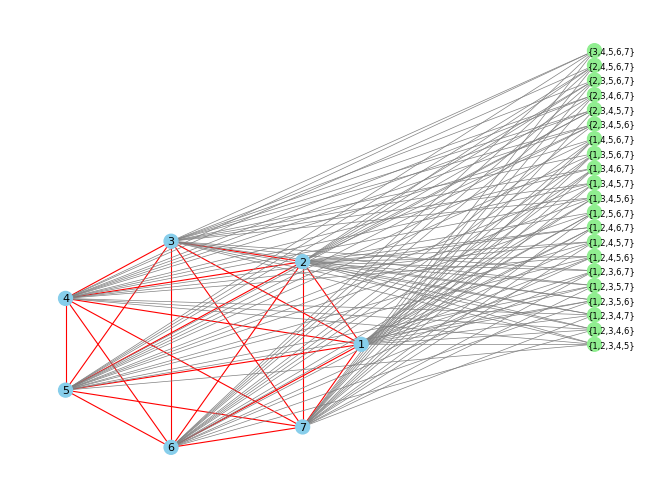

In [11]:
import networkx as nx
from itertools import combinations
import matplotlib.pyplot as plt

def create_G1_with_complete_left():
    """
    Creates a graph where:
    - Left side (1–7) form a complete graph K7
    - Right side: 21 vertices labeled by all 5-element subsets of {1,…,7}
    - Each right vertex connected to its corresponding 5 left vertices
    """
    G = nx.Graph()
    left_nodes = list(range(1, 8))
    G.add_nodes_from(left_nodes, bipartite=0)

    for subset in combinations(left_nodes, 5):
        label = "{" + ",".join(map(str, subset)) + "}"
        G.add_node(label, bipartite=1)
        for v in subset:
            G.add_edge(label, v)

    # Make left-hand nodes a complete graph (K7)
    for u, v in combinations(left_nodes, 2):
        G.add_edge(u, v)

    return G


# Create the graph
G1 = create_G1_with_complete_left()

# Identify left/right nodes
left_nodes = [n for n, d in G1.nodes(data=True) if d["bipartite"] == 0]
right_nodes = [n for n in G1 if n not in left_nodes]

# Layout: left-hand side as complete graph (K7)
pos_left = nx.circular_layout(left_nodes, scale=1.8)

# Shift the K7 to the left
for n in pos_left:
    pos_left[n] = (pos_left[n][0] - 2, pos_left[n][1])

# Arrange right-hand nodes vertically to the right
pos_right = {n: (2.5, i * 0.25) for i, n in enumerate(right_nodes)}

# Merge positions
pos = {**pos_left, **pos_right}

# Draw graph
nx.draw(
    G1,
    pos,
    with_labels=False,
    node_size=100,
    node_color=["skyblue" if n in left_nodes else "lightgreen" for n in G1.nodes()],
    edge_color=[
        "red" if (u in left_nodes and v in left_nodes) else "gray" for u, v in G1.edges()
    ],
    width=[
        0.8 if (u in left_nodes and v in left_nodes) else 0.5 for u, v in G1.edges()
    ]
)

# Draw labels (right ones slightly offset)
labels_left = {n: n for n in left_nodes}
labels_right = {n: n for n in right_nodes}
pos_labels_right = {n: (x + 0.2, y) for n, (x, y) in pos_right.items()}

nx.draw_networkx_labels(G1, pos, labels=labels_left, font_size=8)
nx.draw_networkx_labels(G1, pos_labels_right, labels=labels_right, font_size=6)

plt.axis("off")
plt.show()
